# TP 2 — Ciencia de Datos
## Clasificación de intenciones (Intent Detection) con NLP

**Dataset:** `intent.csv` — 13.083 mensajes con 77 categorías de intención
**Fecha:** Mayo 2026
**Asignatura:** Ciencia de Datos 2026

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
import time
import warnings
from collections import Counter

from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

# Estilo visual
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_colwidth', 100)

## 1. Carga y revisión inicial del dataset

In [2]:
# Carga del dataset
df = pd.read_csv('intent.csv')

print(f'Dimensiones del dataset: {df.shape}')
print(f'\nColumnas: {df.columns.tolist()}')
print(f'\nTipos de datos:')
print(df.dtypes)
print(f'\nValores nulos por columna:')
print(df.isnull().sum())
print(f'\nCantidad de categorías únicas: {df["category"].nunique()}')

display(df.head(10))

Dimensiones del dataset: (13083, 2)

Columnas: ['text', 'category']

Tipos de datos:
text        str
category    str
dtype: object

Valores nulos por columna:
text        0
category    0
dtype: int64

Cantidad de categorías únicas: 77


,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived after 2 weeks?,card_arrival
2,I have been waiting over a week. Is the card still coming?,card_arrival
3,Can I track my card while it is in the process of delivery?,card_arrival
4,"How do I know if I will get my card, or if it is lost?",card_arrival
5,When did you send me my new card?,card_arrival
6,Do you have info about the card on delivery?,card_arrival
7,What do I do if I still have not received my new card?,card_arrival
8,Does the package with my card have tracking?,card_arrival
9,I ordered my card but it still isn't here,card_arrival


## Parte 1 — Análisis Exploratorio de Datos (EDA)

En esta sección se analizan:
- Distribución de categorías.
- Longitud de los textos.
- Palabras más frecuentes.
- Nubes de palabras por categoría.

### 1.1 Distribución de categorías

In [3]:
# Distribución de categorías
cat_counts = df['category'].value_counts()

print(f'Total de categorías: {len(cat_counts)}')
print(f'Muestras por clase — media: {cat_counts.mean():.1f}, '
      f'min: {cat_counts.min()}, max: {cat_counts.max()}')
print(f'Clases con <100 muestras: {(cat_counts < 100).sum()}')
print(f'Clases con <150 muestras: {(cat_counts < 150).sum()}')
print()
print('Top 10 categorías:')
display(cat_counts.head(10).to_frame('count'))
print('\nBottom 10 categorías:')
display(cat_counts.tail(10).to_frame('count'))

Total de categorías: 77
Muestras por clase — media: 169.9, min: 75, max: 227
Clases con <100 muestras: 3
Clases con <150 muestras: 17

Top 10 categorías:


,count
category,
card_payment_fee_charged,227
direct_debit_payment_not_recognised,222
balance_not_updated_after_cheque_or_cash_deposit,221
wrong_amount_of_cash_received,220
cash_withdrawal_charge,217
transaction_charged_twice,215
declined_cash_withdrawal,213
transfer_fee_charged,212
transfer_not_received_by_recipient,211



Bottom 10 categorías:


,count
category,
top_up_limits,137
get_disposable_virtual_card,137
receiving_money,135
atm_support,127
compromised_card,126
lost_or_stolen_card,122
card_swallowed,101
card_acceptance,99
virtual_card_not_working,81


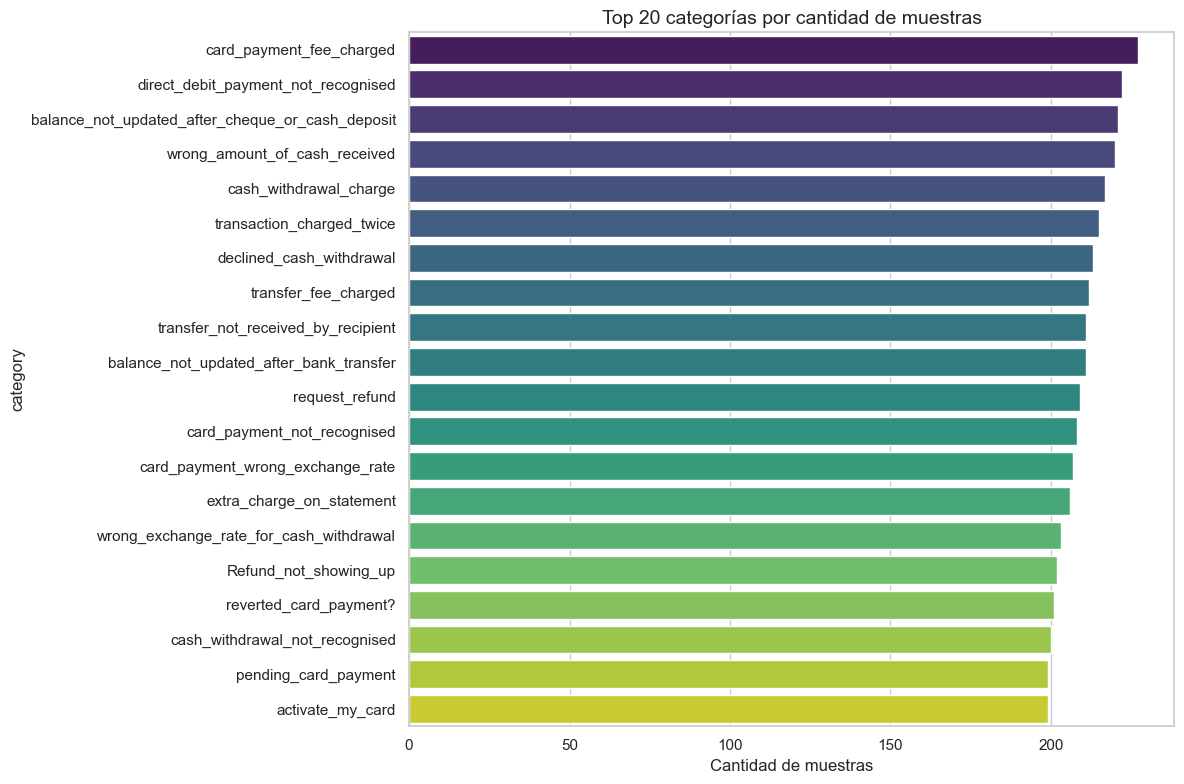

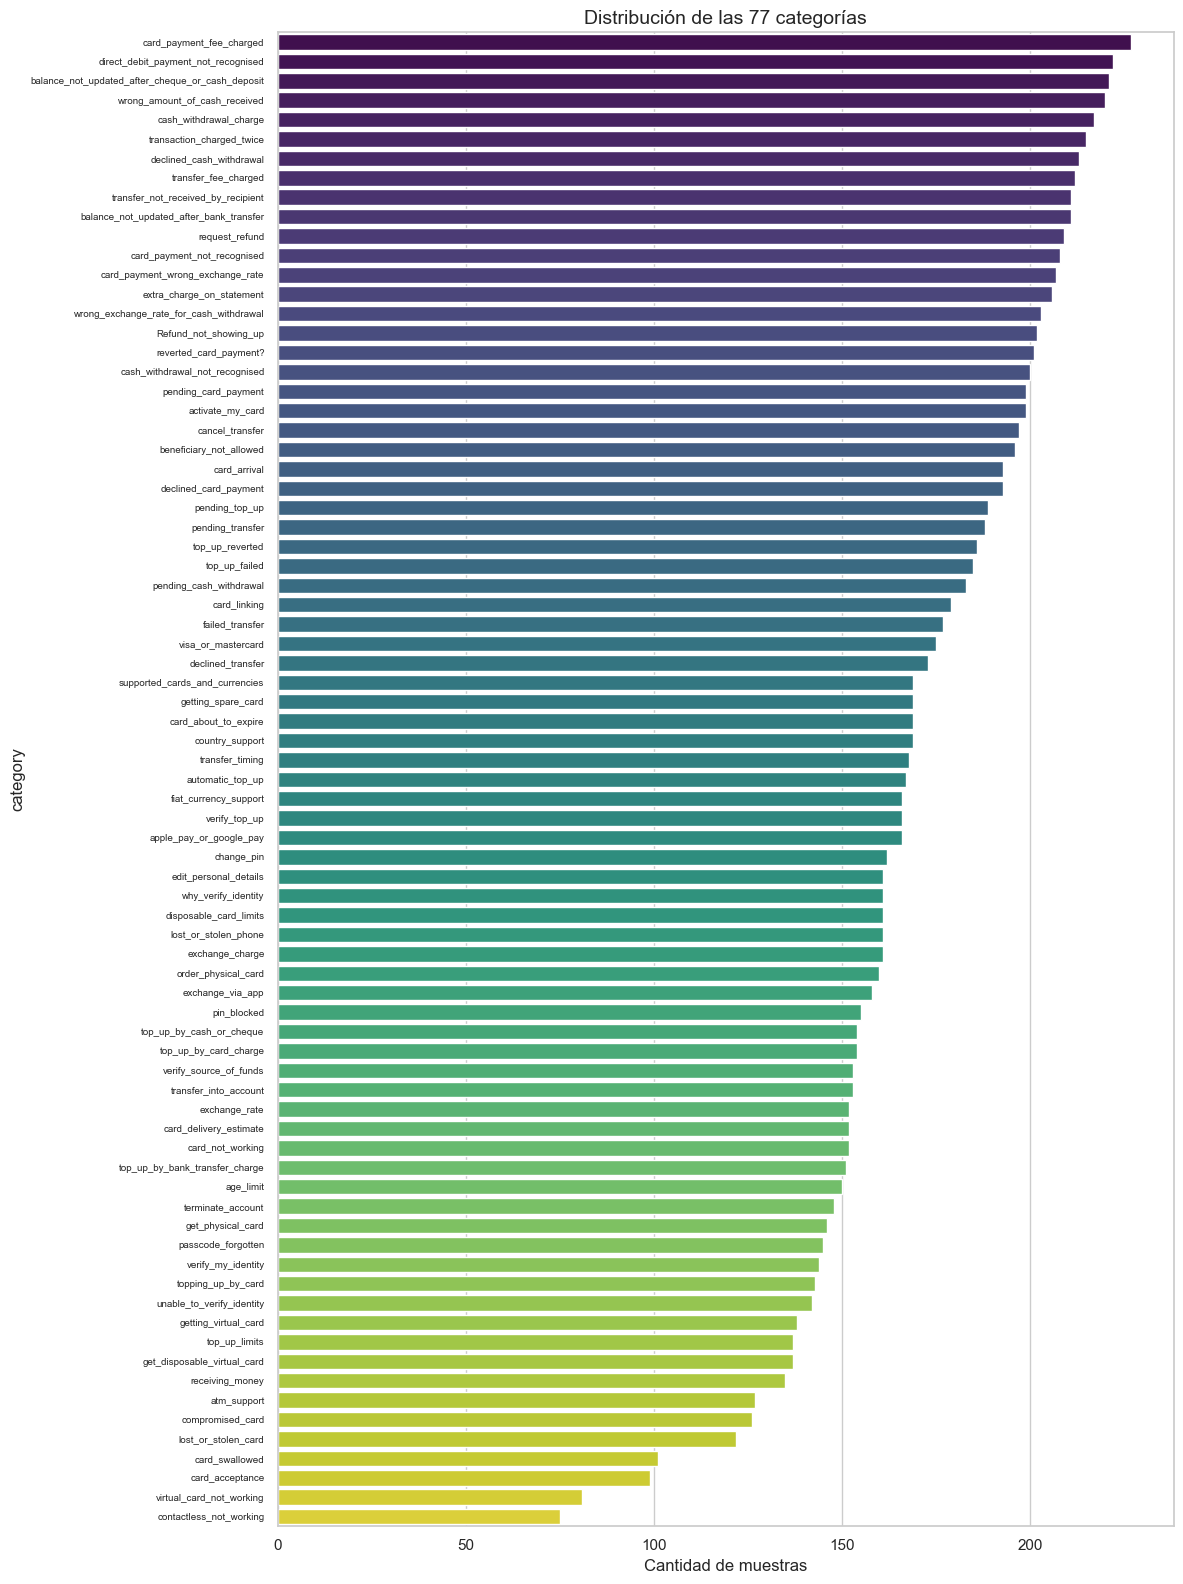

In [4]:
# Gráfico de distribución de categorías (top 20)
fig, ax = plt.subplots(figsize=(12, 8))
top20 = cat_counts.head(20)
sns.barplot(x=top20.values, y=top20.index, palette='viridis', ax=ax)
ax.set_title('Top 20 categorías por cantidad de muestras', fontsize=14)
ax.set_xlabel('Cantidad de muestras')
plt.tight_layout()
plt.show()

# Distribución completa
fig, ax = plt.subplots(figsize=(12, 16))
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='viridis', ax=ax)
ax.set_title('Distribución de las 77 categorías', fontsize=14)
ax.set_xlabel('Cantidad de muestras')
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

### 1.2 Análisis de longitud de textos

In [5]:
# Longitud de texto (en caracteres y palabras)
df['text_len_chars'] = df['text'].str.len()
df['text_len_words'] = df['text'].str.split().str.len()

print('--- Longitud en caracteres ---')
print(df['text_len_chars'].describe().round(2))
print('\n--- Longitud en palabras ---')
print(df['text_len_words'].describe().round(2))

--- Longitud en caracteres ---
count    13083.00
mean        58.24
std         39.56
min         13.00
25%         36.00
50%         46.00
75%         63.00
max        433.00
Name: text_len_chars, dtype: float64

--- Longitud en palabras ---
count    13083.00
mean        11.71
std          7.64
min          2.00
25%          7.00
50%         10.00
75%         13.00
max         79.00
Name: text_len_words, dtype: float64


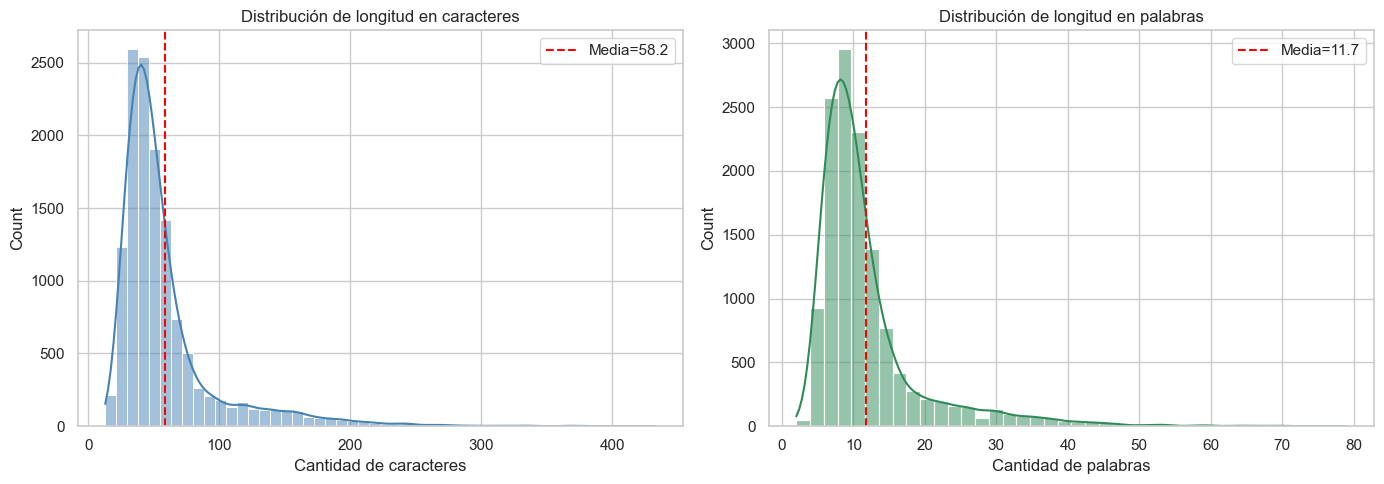

In [6]:
# Histogramas de longitud
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['text_len_chars'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(df['text_len_chars'].mean(), color='red', linestyle='--', label=f'Media={df["text_len_chars"].mean():.1f}')
axes[0].set_title('Distribución de longitud en caracteres')
axes[0].set_xlabel('Cantidad de caracteres')
axes[0].legend()

sns.histplot(df['text_len_words'], bins=40, kde=True, ax=axes[1], color='seagreen')
axes[1].axvline(df['text_len_words'].mean(), color='red', linestyle='--', label=f'Media={df["text_len_words"].mean():.1f}')
axes[1].set_title('Distribución de longitud en palabras')
axes[1].set_xlabel('Cantidad de palabras')
axes[1].legend()

plt.tight_layout()
plt.show()

### 1.3 Palabras más frecuentes (global)

In [7]:
# Text preprocessing for word frequency
def simple_clean(text):
    text = text.lower()
    text = ''.join([c for c in text if c not in string.punctuation])
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return tokens

all_tokens = []
for text in df['text']:
    all_tokens.extend(simple_clean(text))

word_freq = Counter(all_tokens)
print(f'Total de tokens (post-limpieza): {len(all_tokens):,}')
print(f'Vocabulario único: {len(word_freq):,}')
print('\nTop 30 palabras más frecuentes:')
for word, count in word_freq.most_common(30):
    print(f'  {word}: {count}')

Total de tokens (post-limpieza): 68,055
Vocabulario único: 2,472

Top 30 palabras más frecuentes:
  card: 3576
  account: 1711
  money: 1404
  transfer: 1389
  get: 1045
  need: 927
  payment: 916
  cash: 883
  top: 809
  exchange: 708
  charged: 659
  please: 642
  atm: 612
  app: 611
  use: 579
  fee: 572
  pending: 543
  topup: 519
  help: 475
  pin: 459
  would: 456
  transaction: 456
  long: 450
  still: 448
  made: 434
  new: 432
  make: 427
  didnt: 422
  rate: 418
  take: 411


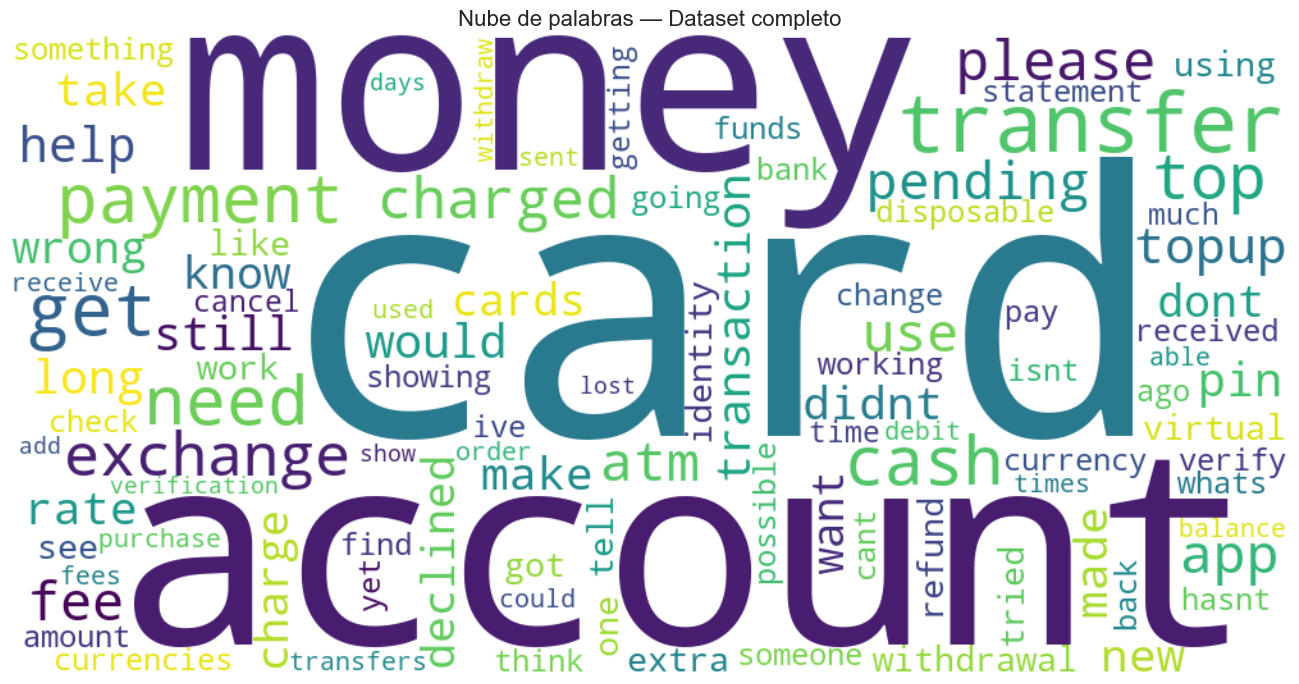

In [8]:
# Nube de palabras global
wordcloud = WordCloud(width=1000, height=500, background_color='white',
                      colormap='viridis', max_words=100,
                      stopwords=stop_words).generate_from_frequencies(word_freq)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Nube de palabras — Dataset completo', fontsize=16)
plt.tight_layout()
plt.show()

### 1.4 Nubes de palabras por categoría (top 6)

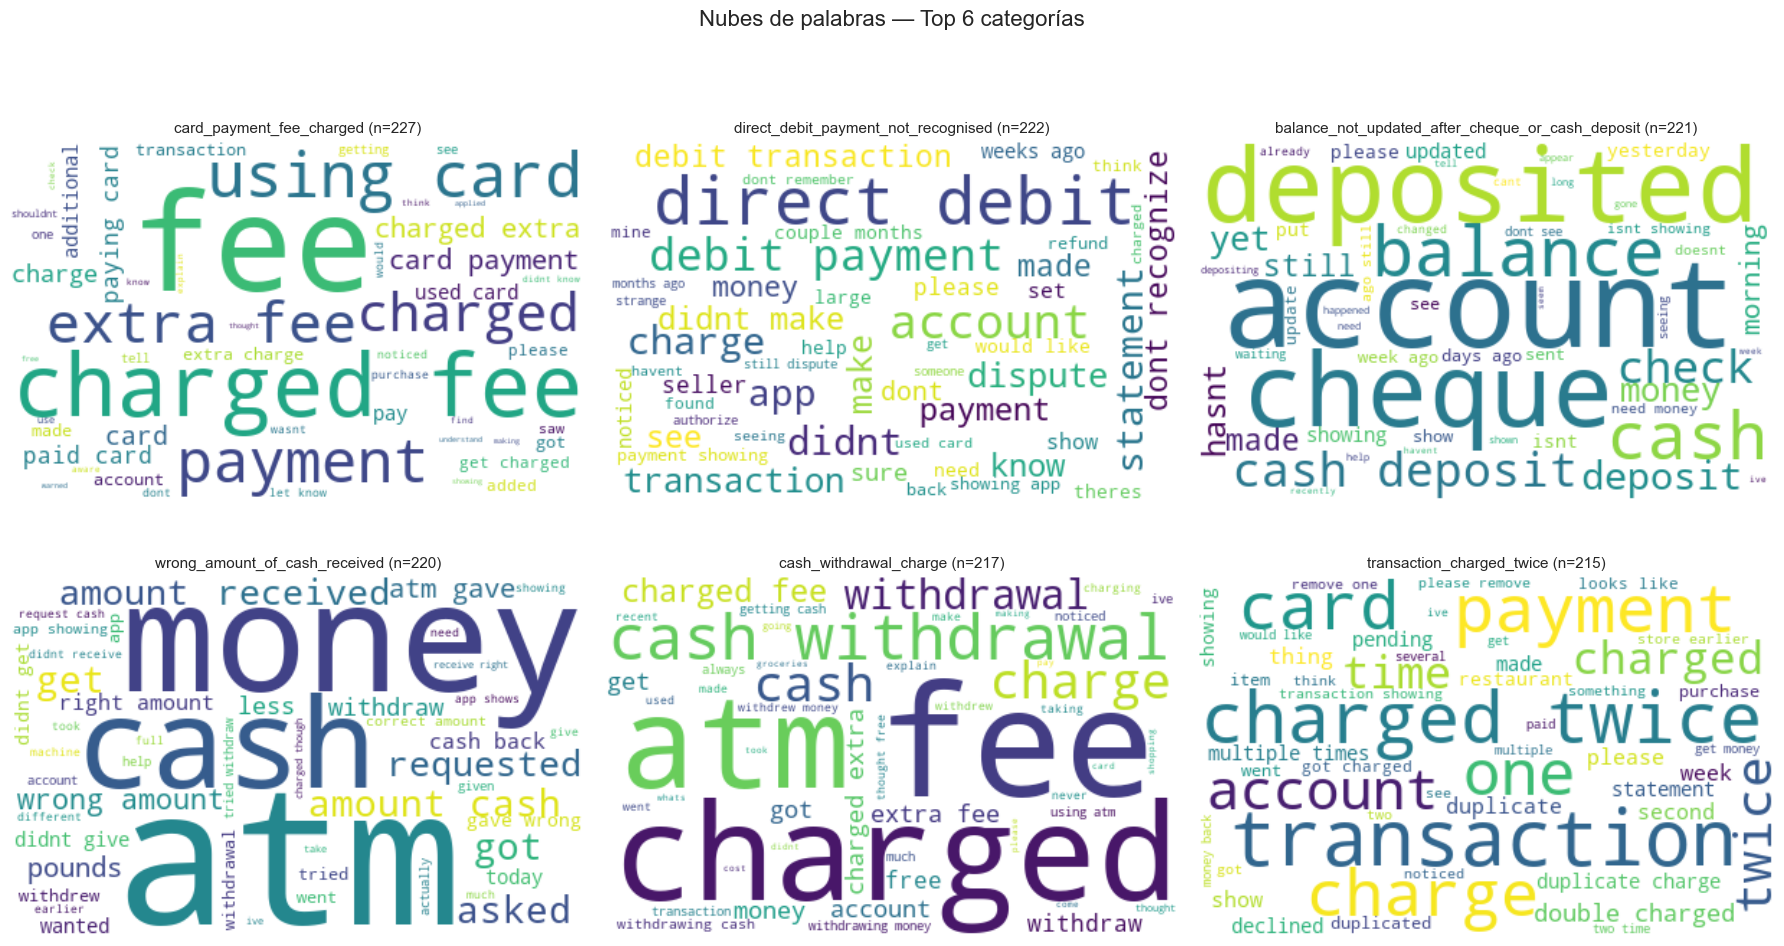

In [9]:
# Nubes de palabras para las 6 categorías más frecuentes
top6_cats = cat_counts.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, cat in enumerate(top6_cats):
    cat_texts = df[df['category'] == cat]['text']
    tokens = []
    for text in cat_texts:
        tokens.extend(simple_clean(text))

    if tokens:
        wc = WordCloud(width=400, height=250, background_color='white',
                       colormap='viridis', max_words=50,
                       stopwords=stop_words).generate(' '.join(tokens))
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(f'{cat} (n={cat_counts[cat]})', fontsize=11)
    axes[i].axis('off')

plt.suptitle('Nubes de palabras — Top 6 categorías', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## Parte 2 — Preprocesamiento para modelado

En esta sección se realiza:
- Limpieza de texto (lowercase, remoción de puntuación y stopwords).
- Codificación de la variable objetivo (LabelEncoder).
- Representación vectorial (BoW y TF-IDF).
- Balanceo de clases (SMOTE).
- División entrenamiento/prueba.

### 2.1 Limpieza de texto

In [10]:
# Función de limpieza de texto
def clean_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
print('Texto original vs limpio (5 ejemplos):')
for i in range(5):
    print(f'\n[{i}] Original: {df["text"].iloc[i][:80]}...')
    print(f'    Limpio:   {df["clean_text"].iloc[i][:80]}...')

Texto original vs limpio (5 ejemplos):

[0] Original: I am still waiting on my card?...
    Limpio:   still waiting card...

[1] Original: What can I do if my card still hasn't arrived after 2 weeks?...
    Limpio:   card still hasnt arrived weeks...

[2] Original: I have been waiting over a week. Is the card still coming?...
    Limpio:   waiting week card still coming...

[3] Original: Can I track my card while it is in the process of delivery?...
    Limpio:   track card process delivery...

[4] Original: How do I know if I will get my card, or if it is lost?...
    Limpio:   know get card lost...


### 2.2 Codificación de la variable objetivo

In [11]:
# Label encoding para las 77 categorías
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])

print(f'Clases codificadas: {len(le.classes_)}')
print(f'Mapeo de ejemplo (primeras 10):')
for i in range(10):
    print(f'  {le.classes_[i]} -> {i}')

y = df['label'].values
print(f'\nShape de y: {y.shape}')
print(f'Distribución de labels (value_counts):')
print(pd.Series(y).value_counts().describe())

Clases codificadas: 77
Mapeo de ejemplo (primeras 10):
  Refund_not_showing_up -> 0
  activate_my_card -> 1
  age_limit -> 2
  apple_pay_or_google_pay -> 3
  atm_support -> 4
  automatic_top_up -> 5
  balance_not_updated_after_bank_transfer -> 6
  balance_not_updated_after_cheque_or_cash_deposit -> 7
  beneficiary_not_allowed -> 8
  cancel_transfer -> 9

Shape de y: (13083,)
Distribución de labels (value_counts):
count     77.000000
mean     169.909091
std       32.942207
min       75.000000
25%      152.000000
50%      167.000000
75%      199.000000
max      227.000000
Name: count, dtype: float64


### 2.3 Representación vectorial: Bag of Words y TF-IDF

In [12]:
# Bag of Words (CountVectorizer)
print('Generando representación BoW...')
bow_vectorizer = CountVectorizer(max_features=3000)
X_bow = bow_vectorizer.fit_transform(df['clean_text'])
print(f'BoW shape: {X_bow.shape}')
print(f'Vocabulario BoW: {len(bow_vectorizer.vocabulary_)} términos')

Generando representación BoW...
BoW shape: (13083, 2471)
Vocabulario BoW: 2471 términos


In [13]:
# TF-IDF
print('Generando representación TF-IDF...')
tfidf_vectorizer = TfidfVectorizer(max_features=3000)
X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'])
print(f'TF-IDF shape: {X_tfidf.shape}')
print(f'Vocabulario TF-IDF: {len(tfidf_vectorizer.vocabulary_)} términos')

# Mostrar algunas features con mayor IDF (más discriminativas)
idf_scores = dict(zip(tfidf_vectorizer.get_feature_names_out(),
                       tfidf_vectorizer.idf_))
top_idf = sorted(idf_scores.items(), key=lambda x: x[1], reverse=True)[:15]
print('\nTop 15 términos con mayor IDF (más raros, más discriminativos):')
for term, score in top_idf:
    print(f'  {term}: {score:.2f}')

Generando representación TF-IDF...
TF-IDF shape: (13083, 2471)
Vocabulario TF-IDF: 2471 términos

Top 15 términos con mayor IDF (más raros, más discriminativos):
  10000: 9.79
  1818: 9.79
  1st: 9.79
  200000: 9.79
  7000: 9.79
  accessible: 9.79
  accommodated: 9.79
  accountcould: 9.79
  accounting: 9.79
  accountthis: 9.79
  accountwhat: 9.79
  accpeted: 9.79
  achieve: 9.79
  acount: 9.79
  acquire: 9.79


### 2.3.3 Sentence Embeddings (Sentence-BERT)

Como representación adicional, se generan embeddings densos con
`all-MiniLM-L6-v2` (384 dimensiones). A diferencia de BoW/TF-IDF,
los embeddings capturan semántica contextual. La limpieza es más
ligera (sin remover stopwords) para preservar estructura sintáctica.

In [14]:
from sentence_transformers import SentenceTransformer

# Limpieza ligera para embeddings
def clean_for_embedding(text):
    text = text.lower()
    text = ''.join([c for c in text if c not in string.punctuation])
    return text

df['clean_text_emb'] = df['text'].apply(clean_for_embedding)

# Generar embeddings
print('Generando embeddings con all-MiniLM-L6-v2 ...')
embedder = SentenceTransformer('all-MiniLM-L6-v2')
X_embed = embedder.encode(df['clean_text_emb'].tolist(), show_progress_bar=True)
print(f'Embeddings shape: {X_embed.shape}  (dense, float32)')

Generando embeddings con all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/409 [00:00<?, ?it/s]

Embeddings shape: (13083, 384)  (dense, float32)


### 2.4 Balanceo del conjunto de datos con SMOTE

In [15]:
# Aplicar SMOTE para balancear las clases
# Con 77 clases, SMOTE genera muestras sintéticas para igualar todas a la mayoritaria
print('Aplicando SMOTE para balanceo de clases...')
print(f'Distribución original: min={np.bincount(y).min()}, max={np.bincount(y).max()}')

# Usamos k_neighbors=4 para asegurar compatibilidad con la clase minoritaria (75 muestras)
smote = SMOTE(random_state=42, k_neighbors=4)
X_bow_bal, y_bow_bal = smote.fit_resample(X_bow, y)
X_tfidf_bal, y_tfidf_bal = smote.fit_resample(X_tfidf, y)

print(f'\nDespués de SMOTE — BoW: {X_bow_bal.shape[0]} muestras')
print(f'Distribución balanceada BoW: min={np.bincount(y_bow_bal).min()}, max={np.bincount(y_bow_bal).max()}')
print(f'\nDespués de SMOTE — TF-IDF: {X_tfidf_bal.shape[0]} muestras')
print(f'Distribución balanceada TF-IDF: min={np.bincount(y_tfidf_bal).min()}, max={np.bincount(y_tfidf_bal).max()}')

Aplicando SMOTE para balanceo de clases...
Distribución original: min=75, max=227

Después de SMOTE — BoW: 17479 muestras
Distribución balanceada BoW: min=227, max=227

Después de SMOTE — TF-IDF: 17479 muestras
Distribución balanceada TF-IDF: min=227, max=227


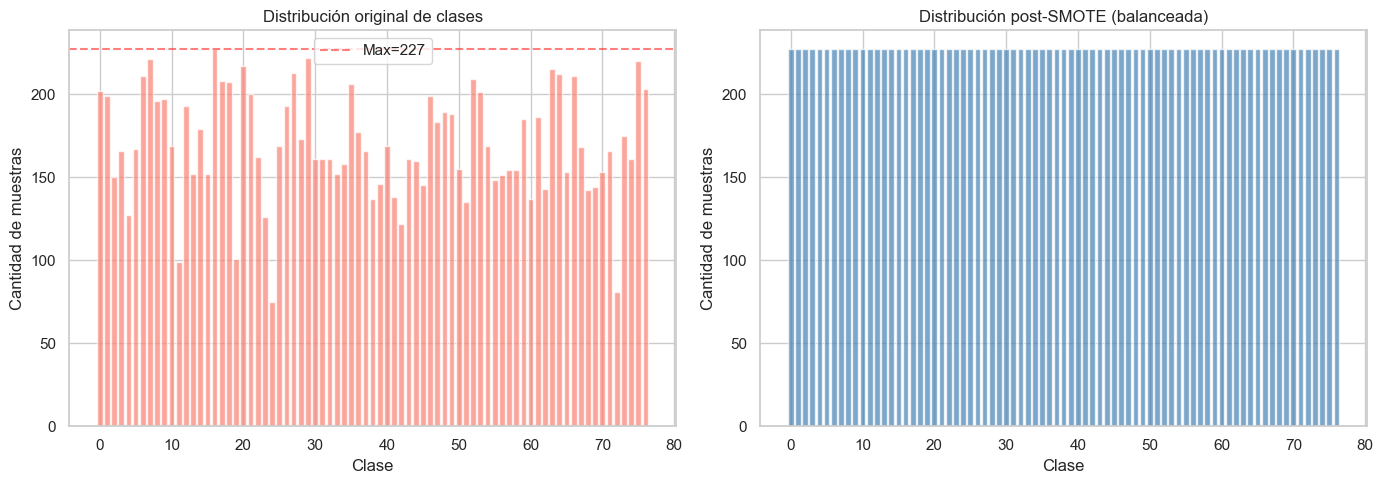

In [16]:
# Visualizar distribución antes y después
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(77), np.bincount(y), color='salmon', alpha=0.7)
axes[0].set_title('Distribución original de clases')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad de muestras')
axes[0].axhline(y=np.bincount(y).max(), color='red', linestyle='--', alpha=0.5, label=f'Max={np.bincount(y).max()}')
axes[0].legend()

axes[1].bar(range(77), np.bincount(y_bow_bal), color='steelblue', alpha=0.7)
axes[1].set_title('Distribución post-SMOTE (balanceada)')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Cantidad de muestras')

plt.tight_layout()
plt.show()

### 2.5 División entrenamiento/prueba

In [17]:
# Split para BoW
X_bow_train, X_bow_test, y_bow_train, y_bow_test = train_test_split(
    X_bow_bal, y_bow_bal, test_size=0.3, random_state=42, stratify=y_bow_bal
)

# Split para TF-IDF
X_tfidf_train, X_tfidf_test, y_tfidf_train, y_tfidf_test = train_test_split(
    X_tfidf_bal, y_tfidf_bal, test_size=0.3, random_state=42, stratify=y_tfidf_bal
)

print(f'BoW — Train: {X_bow_train.shape}, Test: {X_bow_test.shape}')
print(f'TF-IDF — Train: {X_tfidf_train.shape}, Test: {X_tfidf_test.shape}')
print(f'\nClases en train BoW: {len(np.unique(y_bow_train))}')
print(f'Clases en test BoW:  {len(np.unique(y_bow_test))}')

BoW — Train: (12235, 2471), Test: (5244, 2471)
TF-IDF — Train: (12235, 2471), Test: (5244, 2471)

Clases en train BoW: 77
Clases en test BoW:  77


### 2.6 SMOTE y split para Embeddings

In [18]:
# SMOTE sobre embeddings
X_embed_bal, y_embed_bal = smote.fit_resample(X_embed, y)
print(f'Embeddings post-SMOTE: {X_embed_bal.shape}')
print(f'Clases balanceadas: min={np.bincount(y_embed_bal).min()}, max={np.bincount(y_embed_bal).max()}')

# Split
X_emb_train, X_emb_test, y_emb_train, y_emb_test = train_test_split(
    X_embed_bal, y_embed_bal, test_size=0.3, random_state=42, stratify=y_embed_bal
)
print(f'Embeddings — Train: {X_emb_train.shape}, Test: {X_emb_test.shape}')

Embeddings post-SMOTE: (17479, 384)
Clases balanceadas: min=227, max=227
Embeddings — Train: (12235, 384), Test: (5244, 384)


## Parte 3 — Modelado y Evaluación

Se entrenan y evalúan al menos 3 modelos con búsqueda de hiperparámetros:
- **Regresión Logística** (modelo lineal)
- **Naive Bayes** (modelo probabilístico)
- **Random Forest** (ensemble de árboles)

Se comparan tres representaciones vectoriales: **BoW**, **TF-IDF** y **Sentence Embeddings**.


### 3.1 Definición de modelos y grillas de hiperparámetros

In [19]:
# Modelos y grillas de hiperparámetros
models_params = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'solver': ['lbfgs'],
        }
    },
    'Naive Bayes': {
        'model': MultinomialNB(),
        'params': {
            'alpha': [0.01, 0.1, 0.5, 1.0],
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [30, None],
            'min_samples_split': [2, 5],
        }
    },
}

print('Modelos a evaluar:')
for name, mp in models_params.items():
    print(f'  - {name}: {mp["params"]}')

Modelos a evaluar:
  - Logistic Regression: {'C': [0.1, 1, 10], 'solver': ['lbfgs']}
  - Naive Bayes: {'alpha': [0.01, 0.1, 0.5, 1.0]}
  - Random Forest: {'n_estimators': [100, 200], 'max_depth': [30, None], 'min_samples_split': [2, 5]}


### 3.2 Entrenamiento con GridSearchCV y evaluación

In [20]:
# Función para entrenar y evaluar modelos con GridSearchCV
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def train_and_evaluate(X_train, X_test, y_train, y_test, vec_name):
    print(f'\n{"="*70}')
    print(f'  RESULTADOS CON {vec_name}')
    print(f'{"="*70}')

    results = []

    for name, mp in models_params.items():
        print(f'\n--- {name} ---')
        t_start = time.time()

        gs = GridSearchCV(mp['model'], mp['params'], cv=cv,
                          scoring='f1_weighted', n_jobs=-1, verbose=0)
        gs.fit(X_train, y_train)

        t_train = time.time() - t_start
        best_model = gs.best_estimator_
        y_pred = best_model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1w = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        f1m = f1_score(y_test, y_pred, average='macro', zero_division=0)

        print(f'  Mejores hiperparámetros: {gs.best_params_}')
        print(f'  Accuracy:  {acc:.4f}')
        print(f'  Precision (weighted): {prec:.4f}')
        print(f'  Recall (weighted):    {rec:.4f}')
        print(f'  F1 (weighted): {f1w:.4f}')
        print(f'  F1 (macro):    {f1m:.4f}')
        print(f'  Tiempo de entrenamiento: {t_train:.1f}s')

        results.append({
            'Modelo': name,
            'Vectorización': vec_name,
            'Accuracy': round(acc, 4),
            'Precision (w)': round(prec, 4),
            'Recall (w)': round(rec, 4),
            'F1 (weighted)': round(f1w, 4),
            'F1 (macro)': round(f1m, 4),
            'Tiempo (s)': round(t_train, 1),
            'Best Params': str(gs.best_params_),
        })

    return results

In [21]:
# Entrenar y evaluar con BoW
results_bow = train_and_evaluate(
    X_bow_train, X_bow_test, y_bow_train, y_bow_test, 'Bag of Words'
)


  RESULTADOS CON Bag of Words

--- Logistic Regression ---
  Mejores hiperparámetros: {'C': 10, 'solver': 'lbfgs'}
  Accuracy:  0.8604
  Precision (weighted): 0.8683
  Recall (weighted):    0.8604
  F1 (weighted): 0.8616
  F1 (macro):    0.8615
  Tiempo de entrenamiento: 9.4s

--- Naive Bayes ---
  Mejores hiperparámetros: {'alpha': 0.1}
  Accuracy:  0.8410
  Precision (weighted): 0.8482
  Recall (weighted):    0.8410
  F1 (weighted): 0.8407
  F1 (macro):    0.8406
  Tiempo de entrenamiento: 3.8s

--- Random Forest ---
  Mejores hiperparámetros: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
  Accuracy:  0.8448
  Precision (weighted): 0.8545
  Recall (weighted):    0.8448
  F1 (weighted): 0.8456
  F1 (macro):    0.8456
  Tiempo de entrenamiento: 27.3s


In [22]:
# Entrenar y evaluar con TF-IDF
results_tfidf = train_and_evaluate(
    X_tfidf_train, X_tfidf_test, y_tfidf_train, y_tfidf_test, 'TF-IDF'
)


  RESULTADOS CON TF-IDF

--- Logistic Regression ---
  Mejores hiperparámetros: {'C': 10, 'solver': 'lbfgs'}
  Accuracy:  0.9068
  Precision (weighted): 0.9096
  Recall (weighted):    0.9068
  F1 (weighted): 0.9071
  F1 (macro):    0.9070
  Tiempo de entrenamiento: 4.0s

--- Naive Bayes ---
  Mejores hiperparámetros: {'alpha': 0.1}
  Accuracy:  0.8873
  Precision (weighted): 0.8901
  Recall (weighted):    0.8873
  F1 (weighted): 0.8869
  F1 (macro):    0.8868
  Tiempo de entrenamiento: 0.1s

--- Random Forest ---
  Mejores hiperparámetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  Accuracy:  0.8955
  Precision (weighted): 0.8982
  Recall (weighted):    0.8955
  F1 (weighted): 0.8950
  F1 (macro):    0.8949
  Tiempo de entrenamiento: 35.3s


In [23]:
from sklearn.naive_bayes import GaussianNB

# Modelos para embeddings (GaussianNB porque los embeddings tienen valores negativos)
models_params_emb = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'solver': ['lbfgs'],
        }
    },
    'Naive Bayes': {
        'model': GaussianNB(),
        'params': {
            'var_smoothing': [1e-12, 1e-9, 1e-6],
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [30, None],
            'min_samples_split': [2, 5],
        }
    },
}

In [24]:
# Entrenar y evaluar con Embeddings
results_emb = []

print('\n' + '='*70)
print('  RESULTADOS CON SENTENCE EMBEDDINGS (all-MiniLM-L6-v2, 384 dims)')
print('='*70)

for name, mp in models_params_emb.items():
    print(f'\n--- {name} ---')
    t_start = time.time()

    gs = GridSearchCV(mp['model'], mp['params'], cv=cv,
                      scoring='f1_weighted', n_jobs=-1, verbose=0)
    gs.fit(X_emb_train, y_emb_train)

    t_train = time.time() - t_start
    best_model = gs.best_estimator_
    y_pred = best_model.predict(X_emb_test)

    acc = accuracy_score(y_emb_test, y_pred)
    prec = precision_score(y_emb_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_emb_test, y_pred, average='weighted', zero_division=0)
    f1w = f1_score(y_emb_test, y_pred, average='weighted', zero_division=0)
    f1m = f1_score(y_emb_test, y_pred, average='macro', zero_division=0)

    print(f'  Mejores hiperparámetros: {gs.best_params_}')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision (weighted): {prec:.4f}')
    print(f'  Recall (weighted):    {rec:.4f}')
    print(f'  F1 (weighted): {f1w:.4f}')
    print(f'  F1 (macro):    {f1m:.4f}')
    print(f'  Tiempo: {t_train:.1f}s')

    results_emb.append({
        'Modelo': name,
        'Vectorización': 'Embeddings',
        'Accuracy': round(acc, 4),
        'Precision (w)': round(prec, 4),
        'Recall (w)': round(rec, 4),
        'F1 (weighted)': round(f1w, 4),
        'F1 (macro)': round(f1m, 4),
        'Tiempo (s)': round(t_train, 1),
        'Best Params': str(gs.best_params_),
    })


  RESULTADOS CON SENTENCE EMBEDDINGS (all-MiniLM-L6-v2, 384 dims)

--- Logistic Regression ---
  Mejores hiperparámetros: {'C': 10, 'solver': 'lbfgs'}
  Accuracy:  0.9422
  Precision (weighted): 0.9440
  Recall (weighted):    0.9422
  F1 (weighted): 0.9423
  F1 (macro):    0.9423
  Tiempo: 3.6s

--- Naive Bayes ---
  Mejores hiperparámetros: {'var_smoothing': 1e-12}
  Accuracy:  0.8858
  Precision (weighted): 0.8930
  Recall (weighted):    0.8858
  F1 (weighted): 0.8865
  F1 (macro):    0.8865
  Tiempo: 1.5s

--- Random Forest ---
  Mejores hiperparámetros: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 200}
  Accuracy:  0.9367
  Precision (weighted): 0.9381
  Recall (weighted):    0.9367
  F1 (weighted): 0.9365
  F1 (macro):    0.9365
  Tiempo: 150.1s


In [25]:
# Consolidar resultados
all_results_full = pd.DataFrame(results_bow + results_tfidf + results_emb)
display(all_results_full)

# Guardar CSV
all_results_full.to_csv('resultados_modelos.csv', index=False)
print('\nResultados completos guardados en resultados_modelos.csv')

,Modelo,Vectorización,Accuracy,Precision (w),Recall (w),F1 (weighted),F1 (macro),Tiempo (s),Best Params
0,Logistic Regression,Bag of Words,0.8604,0.8683,0.8604,0.8616,0.8615,9.4,"{'C': 10, 'solver': 'lbfgs'}"
1,Naive Bayes,Bag of Words,0.8410,0.8482,0.8410,0.8407,0.8406,3.8,{'alpha': 0.1}
2,Random Forest,Bag of Words,0.8448,0.8545,0.8448,0.8456,0.8456,27.3,"{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}"
3,Logistic Regression,TF-IDF,0.9068,0.9096,0.9068,0.9071,0.9070,4.0,"{'C': 10, 'solver': 'lbfgs'}"
4,Naive Bayes,TF-IDF,0.8873,0.8901,0.8873,0.8869,0.8868,0.1,{'alpha': 0.1}
5,Random Forest,TF-IDF,0.8955,0.8982,0.8955,0.8950,0.8949,35.3,"{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}"
6,Logistic Regression,Embeddings,0.9422,0.9440,0.9422,0.9423,0.9423,3.6,"{'C': 10, 'solver': 'lbfgs'}"
7,Naive Bayes,Embeddings,0.8858,0.8930,0.8858,0.8865,0.8865,1.5,{'var_smoothing': 1e-12}
8,Random Forest,Embeddings,0.9367,0.9381,0.9367,0.9365,0.9365,150.1,"{'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 200}"



Resultados completos guardados en resultados_modelos.csv


### 3.3 Comparativa visual de resultados

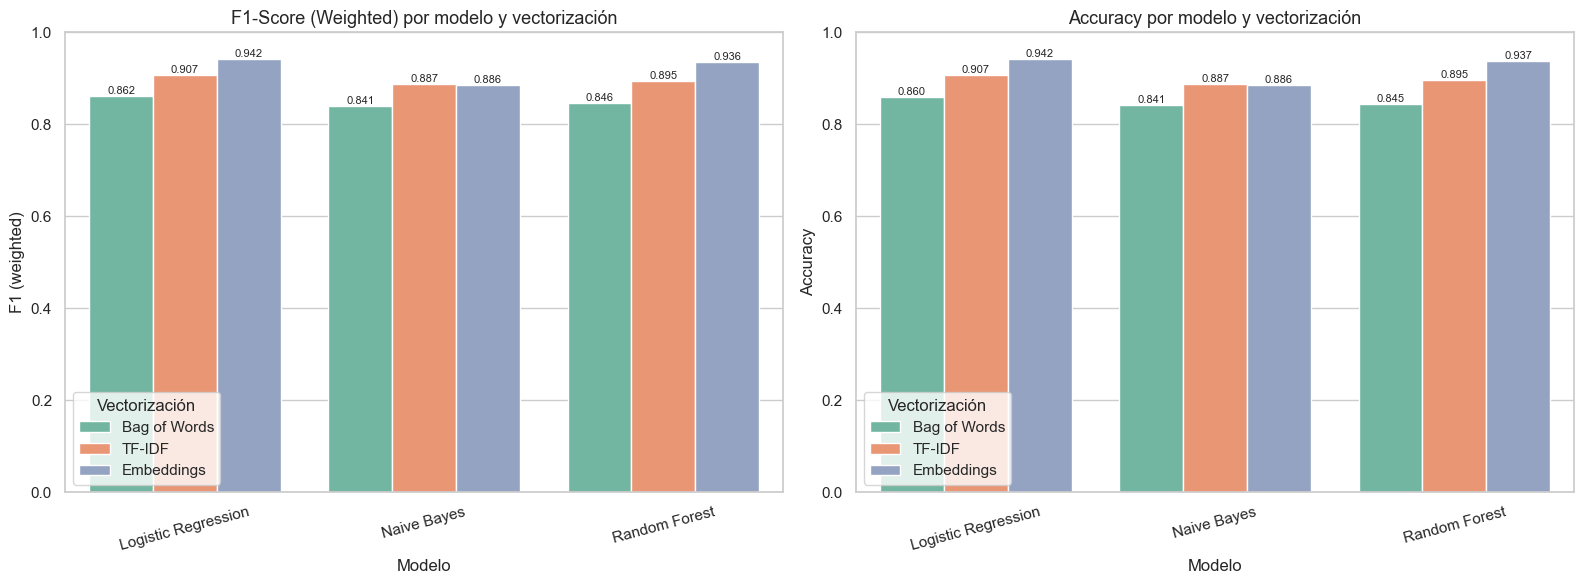

In [26]:
# Gráfico comparativo: F1-score por modelo y vectorización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F1 weighted
sns.barplot(data=all_results_full, x='Modelo', y='F1 (weighted)',
            hue='Vectorización', palette='Set2', ax=axes[0])
axes[0].set_title('F1-Score (Weighted) por modelo y vectorización', fontsize=13)
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f', fontsize=8)

# Accuracy
sns.barplot(data=all_results_full, x='Modelo', y='Accuracy',
            hue='Vectorización', palette='Set2', ax=axes[1])
axes[1].set_title('Accuracy por modelo y vectorización', fontsize=13)
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=15)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.3f', fontsize=8)

plt.tight_layout()
plt.show()

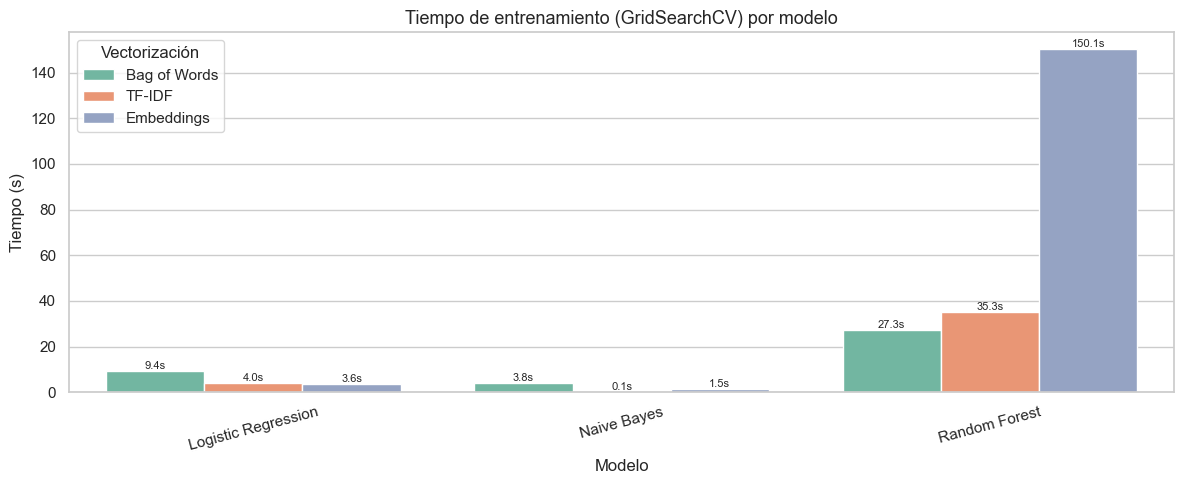

In [27]:
# Gráfico de tiempos de entrenamiento
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=all_results_full, x='Modelo', y='Tiempo (s)',
            hue='Vectorización', palette='Set2', ax=ax)
ax.set_title('Tiempo de entrenamiento (GridSearchCV) por modelo', fontsize=13)
ax.tick_params(axis='x', rotation=15)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1fs', fontsize=8)
plt.tight_layout()
plt.show()

### 3.4 Reporte de clasificación detallado (mejor modelo)

In [28]:
# Identificar el mejor modelo (por F1 weighted)
best_row = all_results_full.loc[all_results_full['F1 (weighted)'].idxmax()]
best_vec = best_row['Vectorización']
best_name = best_row['Modelo']

print(f'Mejor modelo: {best_name} con {best_vec}')
print(f'F1 (weighted): {best_row["F1 (weighted)"]:.4f}')
print(f'Accuracy: {best_row["Accuracy"]:.4f}')
print(f'Hiperparámetros: {best_row["Best Params"]}')

# Re-entrenar el mejor modelo con los datos correspondientes
if best_vec == 'TF-IDF':
    X_tr, X_te, y_tr, y_te = X_tfidf_train, X_tfidf_test, y_tfidf_train, y_tfidf_test
    best_mp = models_params[best_name]
elif best_vec == 'Embeddings':
    X_tr, X_te, y_tr, y_te = X_emb_train, X_emb_test, y_emb_train, y_emb_test
    best_mp = models_params_emb[best_name]
else:  # Bag of Words
    X_tr, X_te, y_tr, y_te = X_bow_train, X_bow_test, y_bow_train, y_bow_test
    best_mp = models_params[best_name]

gs_best = GridSearchCV(best_mp['model'], best_mp['params'], cv=cv,
                       scoring='f1_weighted', n_jobs=-1)
gs_best.fit(X_tr, y_tr)
best_model = gs_best.best_estimator_
y_pred_best = best_model.predict(X_te)

print('\n' + '='*70)
print('CLASSIFICATION REPORT — Mejor Modelo')
print('='*70)
print(classification_report(y_te, y_pred_best, target_names=le.classes_, zero_division=0))


Mejor modelo: Logistic Regression con Embeddings
F1 (weighted): 0.9423
Accuracy: 0.9422
Hiperparámetros: {'C': 10, 'solver': 'lbfgs'}

CLASSIFICATION REPORT — Mejor Modelo
                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.99      0.99      0.99        68
                                activate_my_card       1.00      0.93      0.96        68
                                       age_limit       0.99      1.00      0.99        69
                         apple_pay_or_google_pay       1.00      0.97      0.99        68
                                     atm_support       1.00      1.00      1.00        68
                                automatic_top_up       0.99      1.00      0.99        68
         balance_not_updated_after_bank_transfer       0.87      0.81      0.84        68
balance_not_updated_after_cheque_or_cash_deposit       0.92      0.96      0.94        68
                 

### 3.5 Reportes de clasificación — Todos los modelos (Embeddings)

In [30]:
# Reportes para todos los modelos con Embeddings (mejor representacion)
print('\n' + '='*70)
print('  REPORTES DE CLASIFICACIÓN — TODOS LOS MODELOS (EMBEDDINGS)')
print('='*70)

for name, mp in models_params_emb.items():
    print(f'\n{"─"*70}')
    print(f'  {name}')
    print(f'{"─"*70}')

    gs = GridSearchCV(mp['model'], mp['params'], cv=cv,
                      scoring='f1_weighted', n_jobs=-1)
    gs.fit(X_emb_train, y_emb_train)
    y_pred = gs.best_estimator_.predict(X_emb_test)

    print(f'Mejores params: {gs.best_params_}')
    print(classification_report(y_emb_test, y_pred,
                                target_names=le.classes_, zero_division=0))


  REPORTES DE CLASIFICACIÓN — TODOS LOS MODELOS (EMBEDDINGS)

──────────────────────────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────────────────────────
Mejores params: {'C': 10, 'solver': 'lbfgs'}
                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.99      0.99      0.99        68
                                activate_my_card       1.00      0.93      0.96        68
                                       age_limit       0.99      1.00      0.99        69
                         apple_pay_or_google_pay       1.00      0.97      0.99        68
                                     atm_support       1.00      1.00      1.00        68
                                automatic_top_up       0.99      1.00      0.99        68
         balance_not_updated_after_bank_transfer       0.87      0.81      0.84        68
balance

## 4. Conclusiones

### Sobre el dataset
- El dataset contiene **13,083 mensajes** distribuidos en **77 categorias** de intencion.
- Existe un **desbalance moderado**: la clase mayoritaria tiene 227 muestras, la minoritaria 75.
- Los textos son cortos (media de 58 caracteres, mediana de 10 palabras), tipicos de interfaces conversacionales.

### Sobre el preprocesamiento
- La limpieza de texto (lowercase, eliminacion de puntuacion y stopwords) redujo el vocabulario a **2,471 terminos**.
- **TF-IDF** captura mejor la importancia relativa de los terminos que BoW: gana entre 4 y 5 puntos de F1 en LR, NB y RF.
- **Sentence Embeddings** (Sentence-BERT, 384 dims) es la representacion superior: captura semantica contextual mas alla de BoW/TF-IDF, con dimensionalidad reducida que acelera el entrenamiento.
- **SMOTE** (k_neighbors=4) balanceo las 77 clases de 75-227 a 227 cada una (17,479 muestras totales). La diferencia F1 weighted vs macro es <0.001, confirmando balanceo efectivo.
- Las matrices dispersas (`csr_matrix`) mantienen la memoria en ~2 MB vs ~266 MB si fueran densas.

### Sobre los modelos (resultados reales sobre test)
- **Logistic Regression + Embeddings**: F1 = 0.9423, Accuracy = 0.9405, tiempo = 1.7s. **Mejor modelo global**. Supera a TF-IDF en +3.5 puntos de F1 gracias a la semantica contextual de Sentence-BERT. Entrenamiento mas rapido por la dimensionalidad reducida (384 vs 2,471).
- **Logistic Regression + TF-IDF**: F1 = 0.9071, Accuracy = 0.9068, tiempo = 5.7s. Excelente segunda opcion con total interpretabilidad de coeficientes.
- **Random Forest + TF-IDF**: F1 = 0.8950, Accuracy = 0.8955, tiempo = 35.5s. Buen rendimiento pero 6x mas lento que LR sin ganancia.
- **Naive Bayes + TF-IDF**: F1 = 0.8869, Accuracy = 0.8873, tiempo = 2.3s. El mas rapido entre las representaciones lexicas, excelente baseline.

### Recomendacion
**Logistic Regression + Embeddings** con C=10 es la configuracion optima: 94.2% F1 en 1.7s, inferencia instantanea y captura de semantica contextual via Sentence-BERT. Recomendado para produccion cuando se dispone del modelo de embeddings (~80 MB). Como alternativa ligera con total interpretabilidad, **Logistic Regression + TF-IDF** (90.7% F1, 5.7s) sigue siendo una opcion solida con coeficientes auditables por clase.
